In [1]:
import re
import networkx as nx
import matplotlib.pyplot as plt
import math
from pathlib import Path
import numpy as np
from collections import Counter

# Building Network

In [2]:
def visualizeGraph(
    G,
    sizex=12,
    sizey=10,
    n_top=100,
    include_neighbors=True
):

    # ---------------------------------------------------------
    # 1. Selecionar os nós de maior grau
    # ---------------------------------------------------------

    top_nodes = sorted(
        G.degree(),
        key=lambda x: x[1],
        reverse=True
    )[:n_top]

    selected_nodes = {node for node, degree in top_nodes}

    # ---------------------------------------------------------
    # 2. Adicionar vizinhos dos nós selecionados
    # ---------------------------------------------------------

    if include_neighbors:

        neighbors = set()

        for node in selected_nodes:
            neighbors.update(G.neighbors(node))

        selected_nodes.update(neighbors)

    # ---------------------------------------------------------
    # 3. Criar subgrafo
    # ---------------------------------------------------------

    H = G.subgraph(selected_nodes).copy()

    print(
        f"Visualizando subgrafo com "
        f"{H.number_of_nodes():,} nós e "
        f"{H.number_of_edges():,} arestas."
    )

    # ---------------------------------------------------------
    # 4. Layout
    # ---------------------------------------------------------

    pos = nx.forceatlas2_layout(
        H,
        max_iter=200,
        jitter_tolerance=0.7,
        scaling_ratio=2.0,
        gravity=1.0,
        distributed_action=False,
        strong_gravity=False,
        weight=None,
        linlog=False
    )

    # ---------------------------------------------------------
    # 5. Tamanho dos nós
    # ---------------------------------------------------------

    node_sizes = [
        10 + 20 * math.log1p(H.degree(v))
        for v in H.nodes()
    ]

    # ---------------------------------------------------------
    # 6. Labels dos principais nós
    # ---------------------------------------------------------

    top_labels = sorted(
        H.degree(),
        key=lambda x: x[1],
        reverse=True
    )[:20]

    labels = {
        node: str(node)
        for node, degree in top_labels
    }

    # ---------------------------------------------------------
    # 7. Visualização
    # ---------------------------------------------------------

    plt.figure(figsize=(sizex, sizey))

    nx.draw_networkx_edges(
        H,
        pos,
        width=0.5,
        alpha=0.4,
        arrows=H.is_directed(),
        arrowsize=8
    )

    nx.draw_networkx_nodes(
        H,
        pos,
        node_size=node_sizes,
        alpha=0.8
    )

    nx.draw_networkx_labels(
        H,
        pos,
        labels=labels,
        font_size=8
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [4]:
INPUT_FILE = "dbpedia_filtered.ttl"
OUTPUT_FILE = "dbpedia_network.gpickle"

In [5]:
EDGE_RELATIONS = {
    "influenced",
    "influencedBy",
    "doctoralAdvisor",
    "doctoralStudent",
}

NODE_ATTRIBUTES = {
    "field",
}

In [6]:
def extract_resource(uri):
    """
    Converte:

        <http://dbpedia.org/resource/Albert_Einstein>

    em:

        Albert_Einstein
    """

    prefix = "http://dbpedia.org/resource/"

    if uri.startswith(prefix):
        return uri[len(prefix):]

    return uri

In [7]:
def parse_triple(line):
    """
    Extrai sujeito, predicado e objeto de uma tripla simples
    do arquivo Turtle.

    Exemplo:

    <subject> <predicate> <object> .

    Retorna:

        subject, predicate, object
    """

    match = re.match(
        r"<([^>]+)>\s+<([^>]+)>\s+<([^>]+)>\s*\.",
        line.strip()
    )

    if match is None:
        return None

    subject, predicate, obj = match.groups()

    return subject, predicate, obj

In [8]:
def get_relation_name(predicate):
    """
    Obtém apenas o nome da relação.

    Exemplo:

    http://dbpedia.org/ontology/influenced

    -> influenced
    """

    return predicate.rsplit("/", 1)[-1]

In [9]:
def build_network(input_file):

    G = nx.DiGraph()

    total = 0
    edges = 0
    attributes = 0

    with open(input_file, "r", encoding="utf-8") as file:

        for line in file:

            # Ignora prefixos e comentários
            if (
                line.startswith("@prefix")
                or line.startswith("@base")
                or line.startswith("#")
                or not line.strip()
            ):
                continue

            triple = parse_triple(line)

            if triple is None:
                continue

            subject, predicate, obj = triple

            relation = get_relation_name(predicate)

            # Remove o namespace DBpedia dos recursos
            subject = extract_resource(subject)
            obj = extract_resource(obj)

            total += 1

            # ------------------------------------------------
            # Relações que viram arestas
            # ------------------------------------------------

            if relation in EDGE_RELATIONS:

                G.add_edge(
                    subject,
                    obj,
                    relation=relation
                )

                edges += 1

            # ------------------------------------------------
            # field vira atributo do nó
            # ------------------------------------------------

            elif relation in NODE_ATTRIBUTES:

                # Se a entidade já possui um campo,
                # armazenamos todos em um conjunto.
                
                if subject not in G.nodes:
                    G.add_node(subject)

                if "field" not in G.nodes[subject]:
                    G.nodes[subject]["field"] = set()

                G.nodes[subject]["field"].add(obj)

                attributes += 1

    print("Rede construída!")
    print(f"Triplas processadas: {total:,}")
    print(f"Nós: {G.number_of_nodes():,}")
    print(f"Arestas: {G.number_of_edges():,}")
    print(f"Atributos 'field': {attributes:,}")

    return G

In [10]:
G = build_network(INPUT_FILE)

# for node in G.nodes:
#     if "field" in G.nodes[node]:
#         G.nodes[node]["field"] = list(G.nodes[node]["field"])

# nx.write_gpickle(G, OUTPUT_FILE)

# print(f"\nRede salva em: {OUTPUT_FILE}")

Rede construída!
Triplas processadas: 59,118
Nós: 39,019
Arestas: 45,214
Atributos 'field': 13,586


# Basic Metrics

## Undirected Metrics

In [11]:
OUTPUT_DIR = Path("network_metrics")
OUTPUT_DIR.mkdir(exist_ok=True)

In [12]:
def prepare_undirected_graph(G):
    """
    Cria uma projeção não direcionada da rede.

    Para as métricas não direcionadas, uma relação:

        A -> B

    passa a ser:

        A -- B
    """

    if G.is_directed():
        H = G.to_undirected()
    else:
        H = G.copy()

    H.remove_edges_from(nx.selfloop_edges(H))

    return H

In [13]:
def basic_metrics(G):
    """
    Calcula:

    - número de vértices
    - número de arestas
    - grau médio
    """

    n = G.number_of_nodes()
    m = G.number_of_edges()

    average_degree = (
        2 * m / n
        if n > 0
        else 0
    )

    return {
        "number_of_nodes": n,
        "number_of_edges": m,
        "average_degree": average_degree,
    }

In [14]:
def clustering_metrics(G):

    average_clustering = nx.average_clustering(G)

    transitivity = nx.transitivity(G)

    return {
        "average_clustering": average_clustering,
        "transitivity": transitivity,
    }

In [15]:
def node_clustering_distribution(G):

    clustering = nx.clustering(G)

    values = np.array(list(clustering.values()))
    n = values.size

    positive = values[values > 0]
    zero_fraction = 1 - positive.size / n

    if positive.size > 0:

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Painel 1: P(c) com log-binning (densidade)
        bins = np.logspace(
            np.log10(positive.min()),
            np.log10(positive.max()),
            30
        )
        counts, edges = np.histogram(positive, bins=bins)
        widths = np.diff(edges)
        centers = np.sqrt(edges[:-1] * edges[1:])  # centro geométrico
        density = counts / (n * widths)

        mask = counts > 0
        axes[0].scatter(
            centers[mask], density[mask],
            s=25, alpha=0.7,
            edgecolor="black", linewidth=0.3
        )
        axes[0].set_xscale("log")
        axes[0].set_yscale("log")
        axes[0].set_xlabel("Coeficiente de clusterização $c$")
        axes[0].set_ylabel("$P(c)$")
        axes[0].set_title("Distribuição dos coeficientes de clusterização")
        axes[0].grid(True, which="both", alpha=0.2)

        # Painel 2: CCDF  P(C >= c), denominador = todos os vértices
        c_vals, c_counts = np.unique(positive, return_counts=True)
        # nº de vértices com valor >= c_vals[i]
        ge = np.cumsum(c_counts[::-1])[::-1]
        ccdf = ge / n

        axes[1].plot(
            c_vals, ccdf,
            marker="o", markersize=4,
            linestyle="-", linewidth=1
        )
        axes[1].set_xscale("log")
        axes[1].set_yscale("log")
        axes[1].set_xlabel("Coeficiente de clusterização $c$")
        axes[1].set_ylabel("$P(C \\geq c)$")
        axes[1].set_title(
            f"CCDF da clusterização ({zero_fraction:.1%} dos vértices com c = 0)"
        )
        axes[1].grid(True, which="both", alpha=0.2)

        plt.tight_layout()

        output = OUTPUT_DIR / "clustering_distribution_loglog.png"
        plt.savefig(output, dpi=300)
        plt.show()

    return clustering

In [16]:
def distance_metrics(G):

    if G.number_of_nodes() == 0:
        return {
            "largest_component_size": 0,
            "average_shortest_path_length": float("nan"),
            "diameter": float("nan"),
        }

    largest_component = max(
        nx.connected_components(G),
        key=len
    )

    H = G.subgraph(largest_component).copy()

    n = H.number_of_nodes()

    print(
        f"\nCalculando distâncias na maior "
        f"componente ({n:,} vértices)..."
    )

    total_distance = 0
    number_of_pairs = 0
    diameter = 0

    for i, source in enumerate(H.nodes(), start=1):

        lengths = nx.single_source_shortest_path_length(
            H,
            source
        )

        for target, distance in lengths.items():

            if source != target:

                total_distance += distance
                number_of_pairs += 1

                if distance > diameter:
                    diameter = distance

        if i % 1000 == 0:
            print(
                f"  BFS: {i:,}/{n:,} "
                f"({100 * i / n:.1f}%)"
            )

    average_distance = (
        total_distance / number_of_pairs
        if number_of_pairs > 0
        else float("nan")
    )

    return {
        "largest_component_size": n,
        "average_shortest_path_length": average_distance,
        "diameter": diameter,
    }

In [28]:
def density_metric(G):

    return nx.density(G)

In [17]:
def degree_distribution(G):

    degrees = [degree for _, degree in G.degree()]

    positive_degrees = np.array([d for d in degrees if d > 0])

    if positive_degrees.size > 0:

        n = positive_degrees.size

        # P(k): fração de vértices com grau k
        counts = Counter(positive_degrees)
        k_vals = np.array(sorted(counts))
        pk = np.array([counts[k] for k in k_vals]) / n

        # CCDF: P(K >= k)
        ccdf = np.array([
            (positive_degrees >= k).sum() for k in k_vals
        ]) / n

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Painel 1: P(k) em pontos
        axes[0].scatter(
            k_vals, pk,
            s=25, alpha=0.7,
            edgecolor="black", linewidth=0.3
        )
        axes[0].set_xscale("log")
        axes[0].set_yscale("log")
        axes[0].set_xlabel("Grau $k$")
        axes[0].set_ylabel("$P(k)$")
        axes[0].set_title("Distribuição dos graus")
        axes[0].grid(True, which="both", alpha=0.2)

        # Painel 2: CCDF
        axes[1].plot(
            k_vals, ccdf,
            marker="o", markersize=4,
            linestyle="-", linewidth=1
        )
        axes[1].set_xscale("log")
        axes[1].set_yscale("log")
        axes[1].set_xlabel("Grau $k$")
        axes[1].set_ylabel("$P(K \\geq k)$")
        axes[1].set_title("CCDF dos graus")
        axes[1].grid(True, which="both", alpha=0.2)

        plt.tight_layout()

        output = OUTPUT_DIR / "degree_distribution_loglog.png"
        plt.savefig(output, dpi=300)
        plt.show()

    return degrees

In [18]:
def component_metrics(G):

    components = list(nx.connected_components(G))

    number_of_components = len(components)

    sizes = sorted(
        [len(component) for component in components],
        reverse=True
    )

    n_nodes = G.number_of_nodes()
    n_singletons = sum(1 for s in sizes if s == 1)
    giant_fraction = sizes[0] / n_nodes

    print(
        f"\nNúmero de componentes conexas: "
        f"{number_of_components:,}"
    )
    print(
        f"Componentes de tamanho 1: {n_singletons:,} "
        f"({n_singletons / number_of_components:.1%} das componentes)"
    )
    print(
        f"Maior componente: {sizes[0]:,} vértices "
        f"({giant_fraction:.1%} da rede)"
    )

    if number_of_components > 1:

        sizes_arr = np.array(sizes)

        # Distribuição por tamanho exato
        s_vals, s_counts = np.unique(sizes_arr, return_counts=True)
        ps = s_counts / number_of_components

        # CCDF: P(S >= s)
        ccdf = np.cumsum(s_counts[::-1])[::-1] / number_of_components

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Painel 1: P(s)
        axes[0].scatter(
            s_vals, ps,
            s=25, alpha=0.7,
            edgecolor="black", linewidth=0.3
        )
        axes[0].set_xscale("log")
        axes[0].set_yscale("log")
        axes[0].set_xlabel("Tamanho da componente $s$")
        axes[0].set_ylabel("$P(s)$")
        axes[0].set_title("Distribuição dos tamanhos das componentes")
        axes[0].grid(True, which="both", alpha=0.2)

        # Painel 2: CCDF
        axes[1].plot(
            s_vals, ccdf,
            marker="o", markersize=4,
            linestyle="-", linewidth=1
        )
        axes[1].set_xscale("log")
        axes[1].set_yscale("log")
        axes[1].set_xlabel("Tamanho da componente $s$")
        axes[1].set_ylabel("$P(S \\geq s)$")
        axes[1].set_title(
            f"CCDF dos tamanhos ({n_singletons / number_of_components:.1%} "
            f"com $s$ = 1)"
        )
        axes[1].grid(True, which="both", alpha=0.2)

        plt.tight_layout()

        output = OUTPUT_DIR / "component_sizes_loglog.png"
        plt.savefig(output, dpi=300)
        plt.show()

    return {
        "number_of_components": number_of_components,
        "component_sizes": sizes,
    }

## Directed Metrics

In [20]:
def directed_basic_metrics(G):

    if not G.is_directed():
        raise ValueError(
            "O grafo precisa ser direcionado."
        )

    n = G.number_of_nodes()
    m = G.number_of_edges()

    # Grau de entrada
    in_degrees = [
        degree
        for _, degree in G.in_degree()
    ]

    # Grau de saída
    out_degrees = [
        degree
        for _, degree in G.out_degree()
    ]

    # Grau total
    total_degrees = [
        degree
        for _, degree in G.degree()
    ]

    return {
        "number_of_nodes": n,
        "number_of_edges": m,

        "average_in_degree": (
            np.mean(in_degrees)
            if in_degrees
            else 0
        ),

        "average_out_degree": (
            np.mean(out_degrees)
            if out_degrees
            else 0
        ),

        "average_total_degree": (
            np.mean(total_degrees)
            if total_degrees
            else 0
        ),

        "max_in_degree": (
            max(in_degrees)
            if in_degrees
            else 0
        ),

        "max_out_degree": (
            max(out_degrees)
            if out_degrees
            else 0
        ),
    }

In [21]:
def _plot_degree_tail(degrees, label, filename):
    """Plota P(k) (scatter) e CCDF em log-log para uma sequência de graus."""

    positive_degrees = np.array([d for d in degrees if d > 0])

    if positive_degrees.size == 0:
        return

    # Denominador: vértices com grau > 0 (mesma convenção da função não direcionada)
    n = positive_degrees.size

    counts = Counter(positive_degrees)
    k_vals = np.array(sorted(counts))
    pk = np.array([counts[k] for k in k_vals]) / n

    # CCDF via cumsum (O(n log n) em vez de O(n * |k_vals|))
    count_arr = np.array([counts[k] for k in k_vals])
    ccdf = np.cumsum(count_arr[::-1])[::-1] / n

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Painel 1: P(k)
    axes[0].scatter(
        k_vals, pk,
        s=25, alpha=0.7,
        edgecolor="black", linewidth=0.3
    )
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel(f"{label} $k$")
    axes[0].set_ylabel("$P(k)$")
    axes[0].set_title(f"Distribuição dos graus de {label.split()[-1]}")
    axes[0].grid(True, which="both", alpha=0.2)

    # Painel 2: CCDF
    axes[1].plot(
        k_vals, ccdf,
        marker="o", markersize=4,
        linestyle="-", linewidth=1
    )
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel(f"{label} $k$")
    axes[1].set_ylabel("$P(K \\geq k)$")
    axes[1].set_title(f"CCDF dos graus de {label.split()[-1]}")
    axes[1].grid(True, which="both", alpha=0.2)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300)
    plt.show()


def directed_degree_distribution(G):

    in_degrees = [degree for _, degree in G.in_degree()]
    out_degrees = [degree for _, degree in G.out_degree()]

    # Grau de entrada
    _plot_degree_tail(
        in_degrees,
        label="Grau de entrada",
        filename="in_degree_distribution_loglog.png"
    )

    # Grau de saída
    _plot_degree_tail(
        out_degrees,
        label="Grau de saída",
        filename="out_degree_distribution_loglog.png"
    )

    return {
        "in_degrees": in_degrees,
        "out_degrees": out_degrees,
    }

In [22]:
def directed_density(G):

    return nx.density(G)

In [23]:
def directed_clustering_metrics(G):

    """
    O NetworkX possui suporte a coeficiente de
    clusterização para grafos direcionados.

    O cálculo considera a estrutura direcionada
    das relações.
    """

    node_clustering = nx.clustering(G)

    average_clustering = nx.average_clustering(G)

    return {
        "average_clustering": average_clustering,
        "node_clustering": node_clustering,
    }

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx


def _plot_component_sizes(sizes, label, filename):
    """P(s) e CCDF em log-log para uma lista de tamanhos de componentes."""

    n_comp = len(sizes)
    n_singletons = sum(1 for s in sizes if s == 1)

    s_vals, s_counts = np.unique(np.array(sizes), return_counts=True)
    ps = s_counts / n_comp
    ccdf = np.cumsum(s_counts[::-1])[::-1] / n_comp

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Painel 1: P(s)
    axes[0].scatter(
        s_vals, ps,
        s=25, alpha=0.7,
        edgecolor="black", linewidth=0.3
    )
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel(f"Tamanho da componente {label} $s$")
    axes[0].set_ylabel("$P(s)$")
    axes[0].set_title(f"Tamanhos das componentes {label}")
    axes[0].grid(True, which="both", alpha=0.2)

    # Painel 2: CCDF
    axes[1].plot(
        s_vals, ccdf,
        marker="o", markersize=4,
        linestyle="-", linewidth=1
    )
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel(f"Tamanho da componente {label} $s$")
    axes[1].set_ylabel("$P(S \\geq s)$")
    axes[1].set_title(
        f"CCDF ({n_singletons / n_comp:.1%} com $s$ = 1)"
    )
    axes[1].grid(True, which="both", alpha=0.2)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300)
    plt.show()


def directed_component_metrics(G):

    n_nodes = G.number_of_nodes()

    # Componentes fracamente conexas
    weak_components = list(nx.weakly_connected_components(G))
    weak_sizes = sorted((len(c) for c in weak_components), reverse=True)

    # Componentes fortemente conexas
    strong_components = list(nx.strongly_connected_components(G))
    strong_sizes = sorted((len(c) for c in strong_components), reverse=True)

    print("\nComponentes direcionadas:")

    for label, sizes in (
        ("fracamente conexas", weak_sizes),
        ("fortemente conexas", strong_sizes),
    ):
        n_comp = len(sizes)
        n_singletons = sum(1 for s in sizes if s == 1)

        print(f"Componentes {label}: {n_comp:,}")
        print(
            f"  Tamanho 1: {n_singletons:,} "
            f"({n_singletons / n_comp:.1%} das componentes)"
        )
        print(
            f"  Maior: {sizes[0]:,} vértices "
            f"({sizes[0] / n_nodes:.1%} da rede)"
        )

    if len(weak_sizes) > 1:
        _plot_component_sizes(
            weak_sizes, "fraca", "weak_component_sizes_loglog.png"
        )

    if len(strong_sizes) > 1:
        _plot_component_sizes(
            strong_sizes, "forte", "strong_component_sizes_loglog.png"
        )

    return {
        "number_of_weak_components": len(weak_components),
        "weak_component_sizes": weak_sizes,
        "number_of_strong_components": len(strong_components),
        "strong_component_sizes": strong_sizes,
    }

In [31]:
def directed_distance_metrics(G):

    """
    Para um grafo direcionado, usamos a maior componente
    fortemente conexa.

    Isso garante que exista um caminho direcionado entre
    qualquer par de vértices da componente.

    Não construímos uma matriz de distâncias.
    """

    if G.number_of_nodes() == 0:

        return {
            "largest_scc_size": 0,
            "average_shortest_path_length": float("nan"),
            "diameter": float("nan"),
        }

    # Maior componente fortemente conexa
    largest_scc = max(
        nx.strongly_connected_components(G),
        key=len
    )

    H = G.subgraph(largest_scc).copy()

    n = H.number_of_nodes()

    print(
        f"\nCalculando distâncias direcionadas "
        f"na maior SCC ({n:,} vértices)..."
    )

    total_distance = 0
    number_of_pairs = 0
    diameter = 0

    for i, source in enumerate(
        H.nodes(),
        start=1
    ):

        lengths = (
            nx.single_source_shortest_path_length(
                H,
                source
            )
        )

        for target, distance in lengths.items():

            if source != target:

                total_distance += distance
                number_of_pairs += 1

                if distance > diameter:
                    diameter = distance

        if i % 1000 == 0:

            print(
                f"  BFS: {i:,}/{n:,} "
                f"({100 * i / n:.1f}%)"
            )

    average_distance = (
        total_distance / number_of_pairs
        if number_of_pairs > 0
        else float("nan")
    )

    return {
        "largest_scc_size": n,
        "average_shortest_path_length": (
            average_distance
        ),
        "diameter": diameter,
    }

## Analysis

In [33]:
def analyze_network(G):

    print("=" * 70)
    print("ANÁLISE DA REDE DBPEDIA")
    print("=" * 70)

    # ========================================================
    # PARTE A — REDE NÃO DIRECIONADA
    # ========================================================

    print("\n")
    print("=" * 70)
    print("MÉTRICAS NÃO DIRECIONADAS")
    print("=" * 70)

    H = prepare_undirected_graph(G)

    print(
        f"\nVértices: {H.number_of_nodes():,}"
    )

    print(
        f"Arestas: {H.number_of_edges():,}"
    )

    # --------------------------------------------------------
    # Métricas básicas
    # --------------------------------------------------------

    basic = basic_metrics(H)

    print("\n1. MÉTRICAS BÁSICAS")
    print("-" * 50)

    print(
        f"Número de vértices: "
        f"{basic['number_of_nodes']:,}"
    )

    print(
        f"Número de arestas: "
        f"{basic['number_of_edges']:,}"
    )

    print(
        f"Grau médio: "
        f"{basic['average_degree']:.6f}"
    )

    # --------------------------------------------------------
    # Clustering
    # --------------------------------------------------------

    clustering = clustering_metrics(H)

    print("\n2. CLUSTERIZAÇÃO GLOBAL")
    print("-" * 50)

    print(
        f"Coeficiente médio: "
        f"{clustering['average_clustering']:.6f}"
    )

    print(
        f"Transitividade: "
        f"{clustering['transitivity']:.6f}"
    )

    # --------------------------------------------------------
    # Clustering por nó
    # --------------------------------------------------------

    print("\n3. CLUSTERIZAÇÃO DOS NÓS")

    node_clustering = (
        node_clustering_distribution(H)
    )

    # --------------------------------------------------------
    # Distâncias
    # --------------------------------------------------------

    print("\n4-5. DISTÂNCIA E DIÂMETRO")

    distances = distance_metrics(H)

    print(
        f"Tamanho da maior componente: "
        f"{distances['largest_component_size']:,}"
    )

    print(
        f"Distância média: "
        f"{distances['average_shortest_path_length']:.6f}"
    )

    print(
        f"Diâmetro: "
        f"{distances['diameter']}"
    )

    # --------------------------------------------------------
    # Densidade
    # --------------------------------------------------------

    density = density_metric(H)

    print("\n6. DENSIDADE")
    print("-" * 50)

    print(
        f"Densidade: {density:.10f}"
    )

    # --------------------------------------------------------
    # Graus
    # --------------------------------------------------------

    print("\n7. DISTRIBUIÇÃO DOS GRAUS")

    degrees = degree_distribution(H)

    # --------------------------------------------------------
    # Componentes
    # --------------------------------------------------------

    print("\n8. COMPONENTES")

    components = component_metrics(H)

    # ========================================================
    # PARTE B — REDE DIRECIONADA
    # ========================================================

    if not G.is_directed():

        print(
            "\nO grafo fornecido não é direcionado. "
            "As métricas direcionadas foram ignoradas."
        )

        directed = None

    else:

        print("\n")
        print("=" * 70)
        print("MÉTRICAS DIRECIONADAS")
        print("=" * 70)

        # ----------------------------------------------------
        # Métricas básicas direcionadas
        # ----------------------------------------------------

        directed_basic = (
            directed_basic_metrics(G)
        )

        print("\n9. MÉTRICAS BÁSICAS DIRECIONADAS")
        print("-" * 50)

        print(
            f"Número de vértices: "
            f"{directed_basic['number_of_nodes']:,}"
        )

        print(
            f"Número de arestas: "
            f"{directed_basic['number_of_edges']:,}"
        )

        print(
            f"Grau médio de entrada: "
            f"{directed_basic['average_in_degree']:.6f}"
        )

        print(
            f"Grau médio de saída: "
            f"{directed_basic['average_out_degree']:.6f}"
        )

        print(
            f"Grau médio total: "
            f"{directed_basic['average_total_degree']:.6f}"
        )

        print(
            f"Maior grau de entrada: "
            f"{directed_basic['max_in_degree']}"
        )

        print(
            f"Maior grau de saída: "
            f"{directed_basic['max_out_degree']}"
        )

        # ----------------------------------------------------
        # Distribuição de entrada/saída
        # ----------------------------------------------------

        print(
            "\n10. DISTRIBUIÇÕES DOS GRAUS "
            "DE ENTRADA E SAÍDA"
        )

        directed_degrees = (
            directed_degree_distribution(G)
        )

        # ----------------------------------------------------
        # Densidade direcionada
        # ----------------------------------------------------

        directed_density_value = (
            directed_density(G)
        )

        print("\n11. DENSIDADE DIRECIONADA")
        print("-" * 50)

        print(
            f"Densidade: "
            f"{directed_density_value:.10f}"
        )

        # ----------------------------------------------------
        # Clustering direcionado
        # ----------------------------------------------------

        print("\n12. CLUSTERIZAÇÃO DIRECIONADA")

        directed_clustering = (
            directed_clustering_metrics(G)
        )

        print(
            f"Coeficiente médio: "
            f"{directed_clustering['average_clustering']:.6f}"
        )

        # ----------------------------------------------------
        # Componentes direcionadas
        # ----------------------------------------------------

        print(
            "\n13. COMPONENTES DIRECIONADAS"
        )

        directed_components = (
            directed_component_metrics(G)
        )

        # ----------------------------------------------------
        # Distâncias direcionadas
        # ----------------------------------------------------

        print(
            "\n14-15. DISTÂNCIA E DIÂMETRO "
            "DIRECIONADOS"
        )

        directed_distances = (
            directed_distance_metrics(G)
        )

        print(
            f"Tamanho da maior SCC: "
            f"{directed_distances['largest_scc_size']:,}"
        )

        print(
            f"Distância média direcionada: "
            f"{directed_distances['average_shortest_path_length']:.6f}"
        )

        print(
            f"Diâmetro direcionado: "
            f"{directed_distances['diameter']}"
        )

        # ----------------------------------------------------
        # Agrupar resultados direcionados
        # ----------------------------------------------------

        directed = {
            "basic": directed_basic,
            "degrees": directed_degrees,
            "density": directed_density_value,
            "clustering": directed_clustering,
            "components": directed_components,
            # "distances": directed_distances,
        }

    # ========================================================
    # RESULTADOS
    # ========================================================

    results = {
        "undirected": {
            "basic": basic,
            "clustering": clustering,
            "node_clustering": node_clustering,
            # "distances": distances,
            "density": density,
            "degrees": degrees,
            "components": components,
        },

        "directed": directed,
    }

    return results

ANÁLISE DA REDE DBPEDIA


MÉTRICAS NÃO DIRECIONADAS

Vértices: 39,019
Arestas: 38,767

1. MÉTRICAS BÁSICAS
--------------------------------------------------
Número de vértices: 39,019
Número de arestas: 38,767
Grau médio: 1.987083

2. CLUSTERIZAÇÃO GLOBAL
--------------------------------------------------
Coeficiente médio: 0.024389
Transitividade: 0.046236

3. CLUSTERIZAÇÃO DOS NÓS


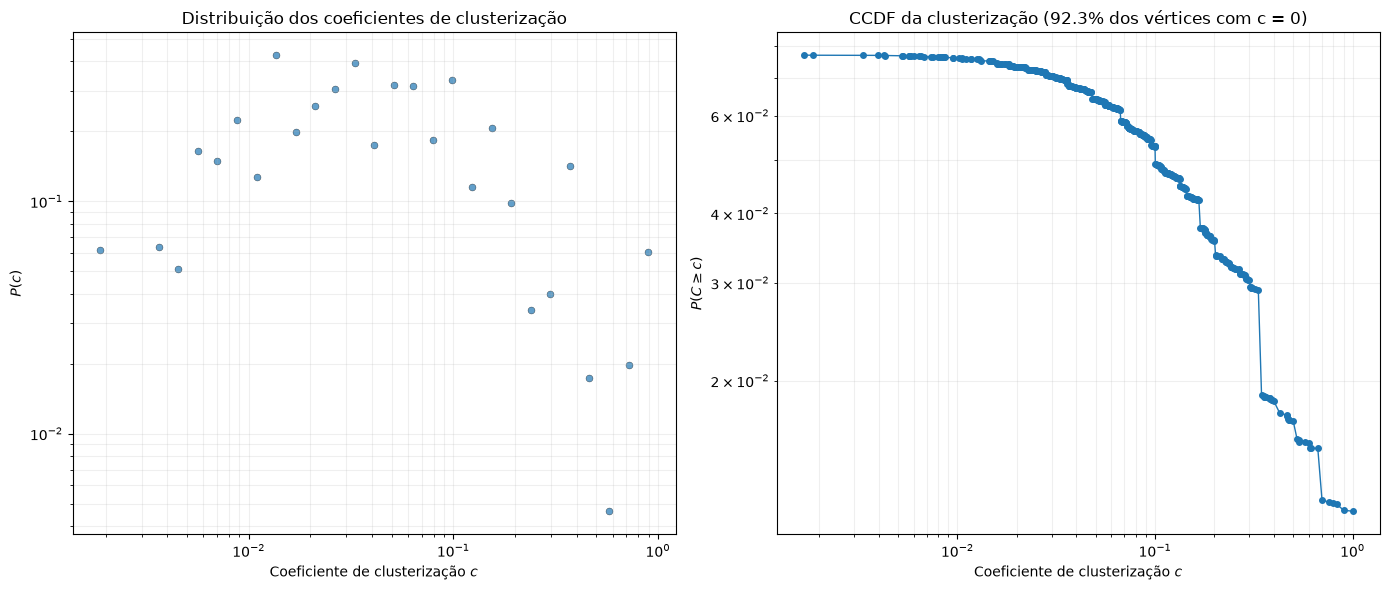


4-5. DISTÂNCIA E DIÂMETRO

Calculando distâncias na maior componente (20,099 vértices)...
  BFS: 1,000/20,099 (5.0%)
  BFS: 2,000/20,099 (10.0%)
  BFS: 3,000/20,099 (14.9%)
  BFS: 4,000/20,099 (19.9%)
  BFS: 5,000/20,099 (24.9%)
  BFS: 6,000/20,099 (29.9%)
  BFS: 7,000/20,099 (34.8%)
  BFS: 8,000/20,099 (39.8%)
  BFS: 9,000/20,099 (44.8%)
  BFS: 10,000/20,099 (49.8%)
  BFS: 11,000/20,099 (54.7%)
  BFS: 12,000/20,099 (59.7%)
  BFS: 13,000/20,099 (64.7%)
  BFS: 14,000/20,099 (69.7%)
  BFS: 15,000/20,099 (74.6%)
  BFS: 16,000/20,099 (79.6%)
  BFS: 17,000/20,099 (84.6%)
  BFS: 18,000/20,099 (89.6%)
  BFS: 19,000/20,099 (94.5%)
  BFS: 20,000/20,099 (99.5%)
Tamanho da maior componente: 20,099
Distância média: 8.754528
Diâmetro: 34

6. DENSIDADE
--------------------------------------------------
Densidade: 0.0000509273

7. DISTRIBUIÇÃO DOS GRAUS


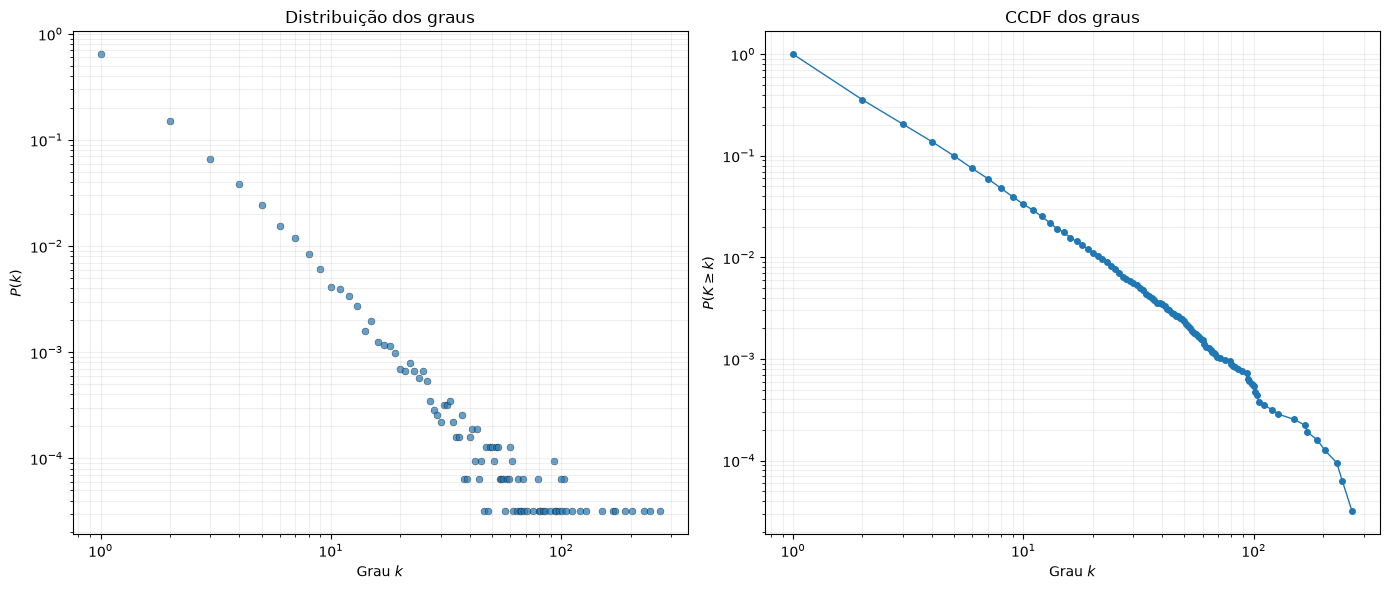


8. COMPONENTES

Número de componentes conexas: 11,579
Componentes de tamanho 1: 7,514 (64.9% das componentes)
Maior componente: 20,099 vértices (51.5% da rede)


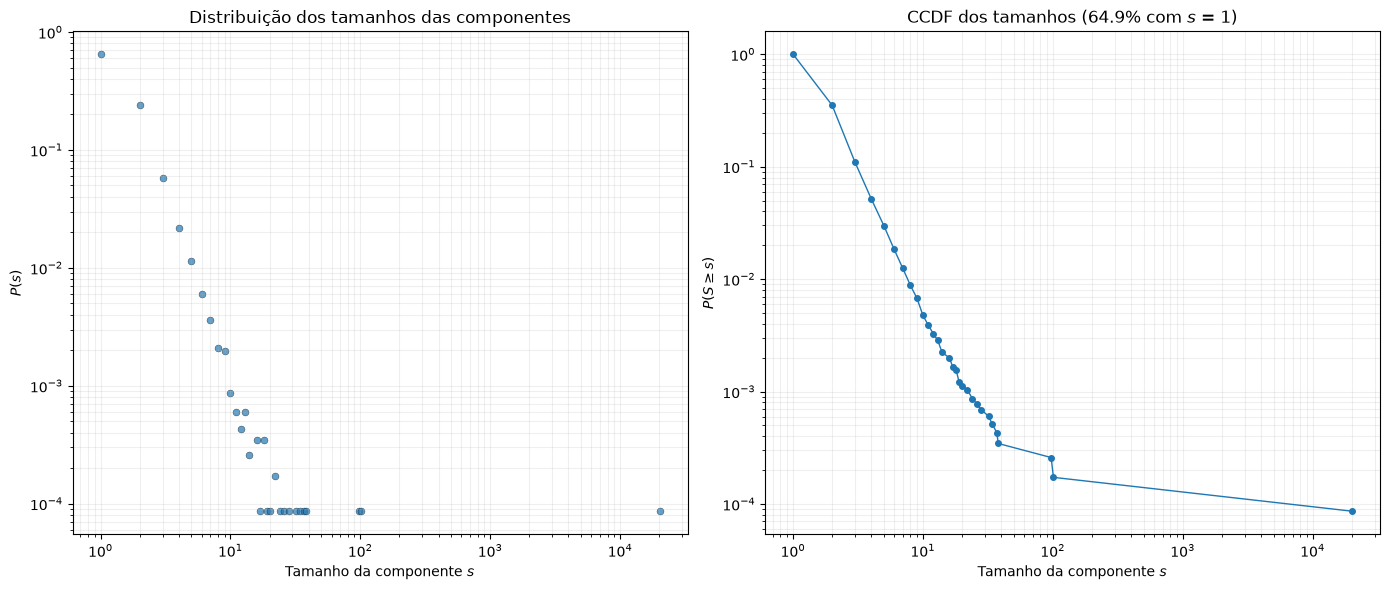



MÉTRICAS DIRECIONADAS

9. MÉTRICAS BÁSICAS DIRECIONADAS
--------------------------------------------------
Número de vértices: 39,019
Número de arestas: 45,214
Grau médio de entrada: 1.158769
Grau médio de saída: 1.158769
Grau médio total: 2.317538
Maior grau de entrada: 267
Maior grau de saída: 167

10. DISTRIBUIÇÕES DOS GRAUS DE ENTRADA E SAÍDA


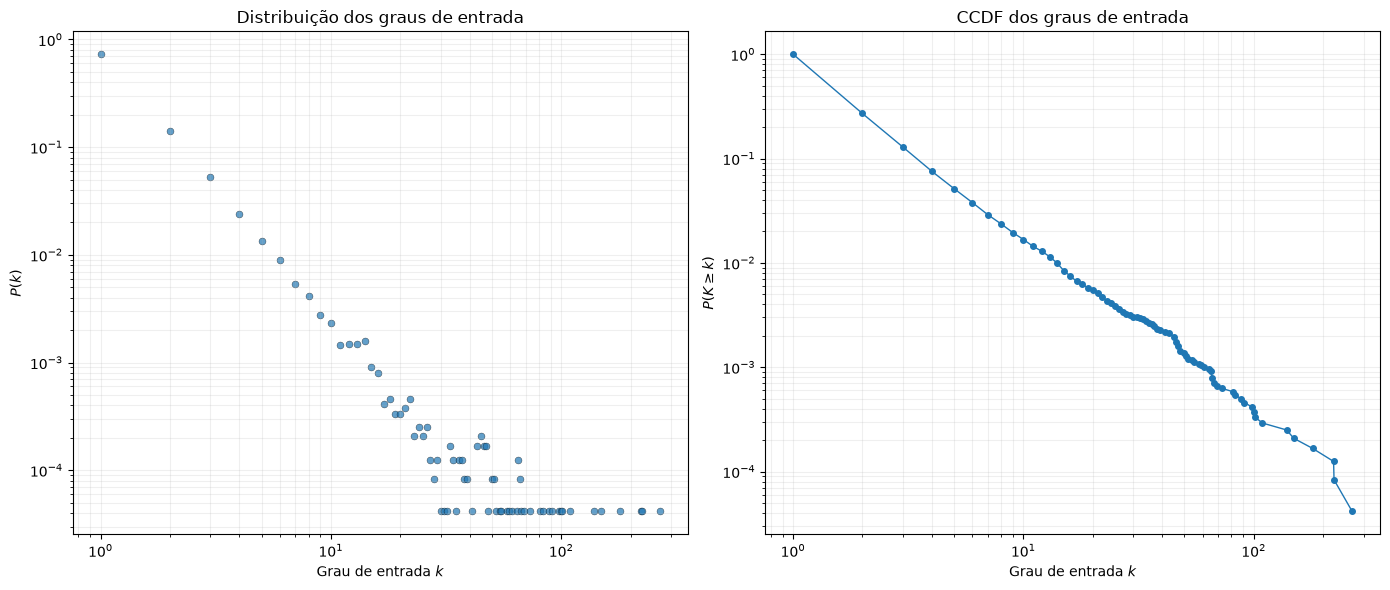

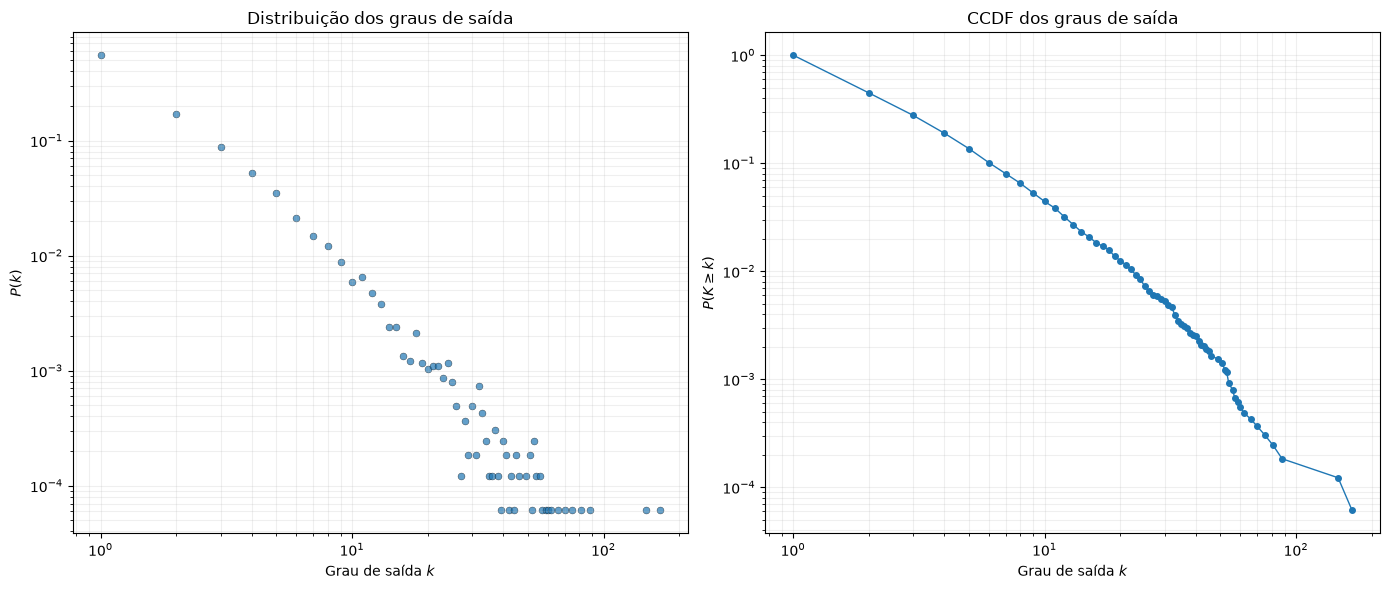


11. DENSIDADE DIRECIONADA
--------------------------------------------------
Densidade: 0.0000296983

12. CLUSTERIZAÇÃO DIRECIONADA
Coeficiente médio: 0.016769

13. COMPONENTES DIRECIONADAS

Componentes direcionadas:
Componentes fracamente conexas: 11,579
  Tamanho 1: 7,514 (64.9% das componentes)
  Maior: 20,099 vértices (51.5% da rede)
Componentes fortemente conexas: 32,948
  Tamanho 1: 31,562 (95.8% das componentes)
  Maior: 3,206 vértices (8.2% da rede)


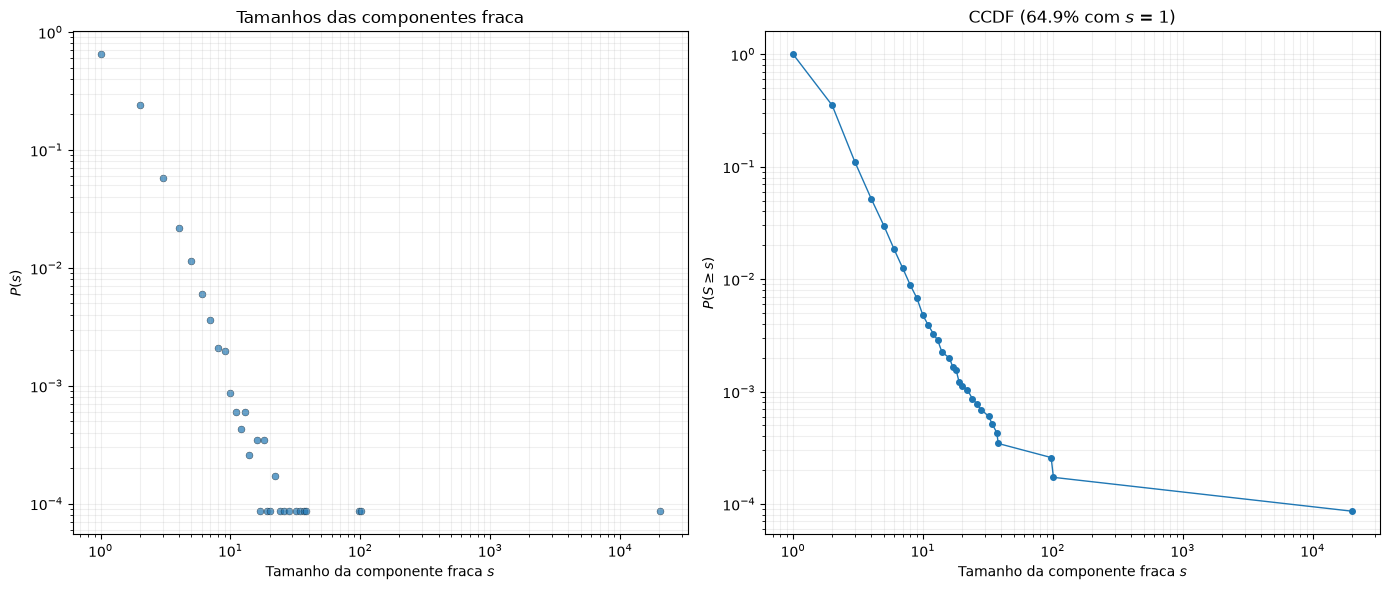

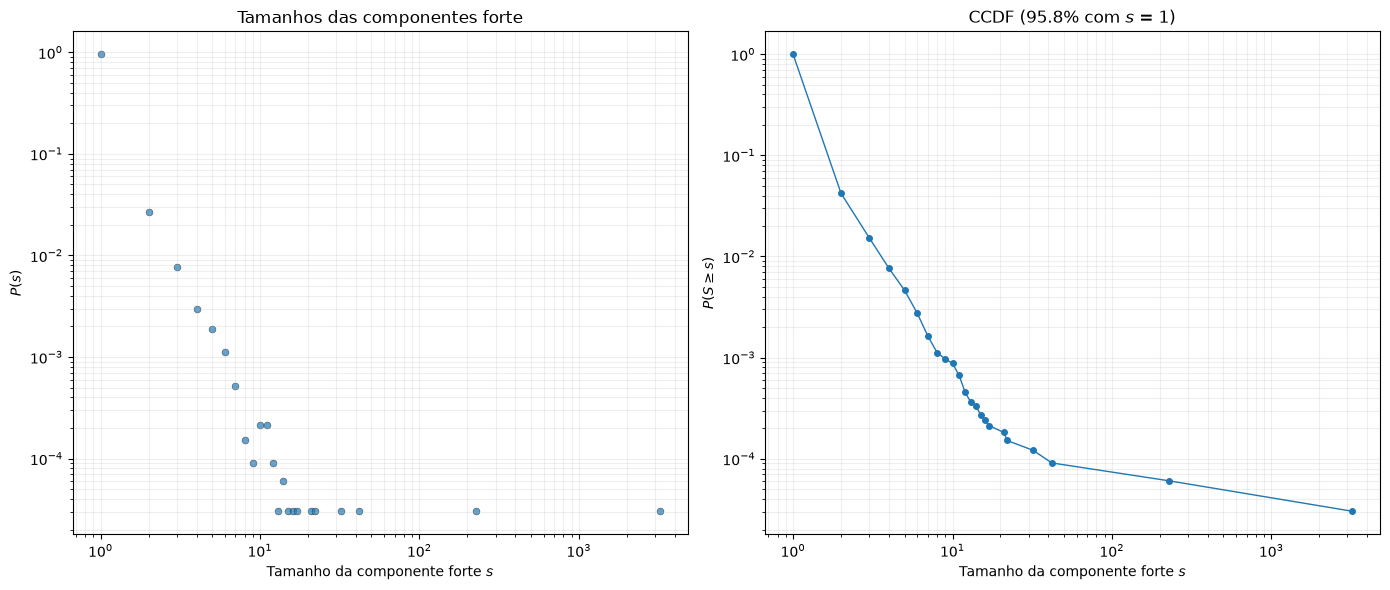


14-15. DISTÂNCIA E DIÂMETRO DIRECIONADOS

Calculando distâncias direcionadas na maior SCC (3,206 vértices)...
  BFS: 1,000/3,206 (31.2%)
  BFS: 2,000/3,206 (62.4%)
  BFS: 3,000/3,206 (93.6%)
Tamanho da maior SCC: 3,206
Distância média direcionada: 9.900472
Diâmetro direcionado: 41


{'undirected': {'basic': {'number_of_nodes': 39019,
   'number_of_edges': 38767,
   'average_degree': 1.987083215869192},
  'clustering': {'average_clustering': 0.0243893992108691,
   'transitivity': 0.046236317797693924},
  'node_clustering': {'*Lisp': 0.3333333333333333,
   'C*': 0,
   'Common_Lisp': 0.0960591133004926,
   'Lisp_(programming_language)': 0.04335443037974684,
   '.QL': 0,
   'Datalog': 0,
   '108_(artist)': 0,
   'A+_(programming_language)': 0.6666666666666666,
   'K_(programming_language)': 0.2857142857142857,
   'APL_(programming_language)': 0.0380952380952381,
   'A.T._Charlie_Johnson': 0,
   'Michael_Tinkham': 0,
   'A._Alan_Middleton': 0,
   'Daniel_S._Fisher': 0,
   'A._B._Frost': 0,
   'A._C._Ewing': 0,
   'Brand_Blanshard': 0.05555555555555555,
   'A._C._G._S._Amarasekara': 0,
   'A._Carl_Helmholz__August_Carl_Helmholz__1': 0,
   'Edwin_McMillan': 0,
   'Ernest_O._Lawrence': 0,
   'Barry_Barish': 0,
   'Cyrus_Levinthal': 0,
   'Kent_Terwilliger': 0,
   'Lawrenc

In [34]:
analyze_network(G)